# Module 2 — Multi-Layer Perceptrons

**DesignSafe AI Training**

[![Try on DesignSafe](https://raw.githubusercontent.com/DesignSafe-CI/training-ai/main/DesignSafe-Badge.svg)](https://jupyter.designsafe-ci.org/hub/user-redirect/lab/tree/CommunityData/Training/training-ai/02-mlp-cantilever.ipynb) [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DesignSafe-CI/training-ai/blob/main/02-mlp/02-mlp-cantilever.ipynb)

---

## MLPs can learn non-linear laws

Module 1 fit a linear regression to 75 OpenSees runs and recovered the period
equation exactly — `[0.5, 1.5, -0.5]` with $R^2 = 1$. It worked because **we knew
to take logarithms.** We supplied the feature transformation, and we could only
supply it because we already knew the answer.

Before going back to the beam, we build the tool that does not need to be told.

## Setup

On DesignSafe JupyterHub most of this is already installed. On Colab the install
takes about a minute.

In [1]:
%pip install torch scikit-learn pandas matplotlib --quiet

/private/tmp/claude-501/-Users-krishna-dev-DesignSafe-Training/a3c591bf-7af0-4642-a72e-3ed72e972147/scratchpad/venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 4321                      # same seed as the SciML course notebook
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})


def find_data(name):
    """Locate a data file whether we are on DesignSafe, Colab, or a laptop."""
    here = Path.cwd()
    for c in [Path("/home/jupyter/CommunityData/Training/training-ai") / name, here / name,
              here / "02-mlp" / name, here.parent / name]:
        if c.exists():
            return c
    url = ("https://raw.githubusercontent.com/DesignSafe-CI/training-ai"
           f"/main/02-mlp/{name}")
    print(f"Not found locally, downloading from {url}")
    return url


print("torch", torch.__version__)

torch 2.13.0


## Part 1 — The function approximation challenge

Start with a problem where we know the answer exactly, so every method can be
scored honestly.

The one-dimensional Poisson equation on $[0,1]$ with homogeneous Dirichlet
boundary conditions:

$$-\frac{d^2u}{dx^2} = f(x), \qquad u(0) = 0, \quad u(1) = 0$$

The same equation models heat conduction in a rod, the deflection of a loaded
beam, and electrostatic potential in 1D — so it is worth knowing well. Choose

$$f(x) = \pi^2 \sin(\pi x) \qquad\Longrightarrow\qquad u(x) = \sin(\pi x)$$

Verify by substitution: $u'' = -\pi^2\sin(\pi x)$, so
$-u'' = \pi^2\sin(\pi x) = f$ ✓, and $u(0) = u(1) = 0$ ✓.

**Keep this problem in mind — Module 4 solves this same equation with a PINN.**

### Can 15 noisy samples recover the solution?

*Can we recover $u(x)$ from a handful of noisy measurements of it?*

That is the situation you are actually in with experimental or simulation data: a
few samples, some noise, a smooth function underneath.

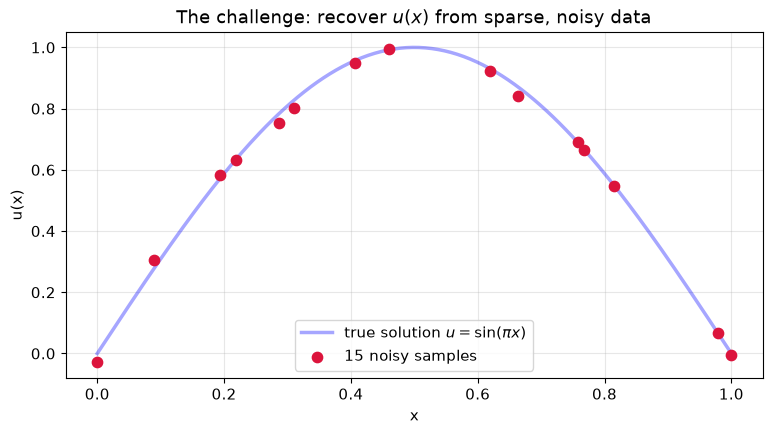

15 samples, noise std 0.02, on a function of amplitude 1


In [3]:
n_train = 15

x_train = np.random.rand(n_train)
x_train[0], x_train[-1] = 0, 1          # include the boundaries
x_train = np.sort(x_train)


def target_func(x):
    """The exact solution of our Poisson problem."""
    return np.sin(np.pi * x)


y_train = target_func(x_train) + 0.02 * np.random.randn(n_train)

x_test = np.linspace(0, 1, 200)
y_exact = target_func(x_test)

plt.figure(figsize=(9, 4.5))
plt.plot(x_test, y_exact, "b-", alpha=.35, lw=2.5,
         label=r"true solution $u=\sin(\pi x)$")
plt.scatter(x_train, y_train, s=55, c="crimson", zorder=5,
            label=f"{n_train} noisy samples")
plt.xlabel("x"); plt.ylabel("u(x)")
plt.title("The challenge: recover $u(x)$ from sparse, noisy data")
plt.legend(); plt.show()

print(f"{n_train} samples, noise std 0.02, on a function of amplitude 1")

### First try: polynomials

The classical answer. With 15 points we can interpolate exactly at degree 14 — so
surely a high-degree polynomial is the best approximation available?

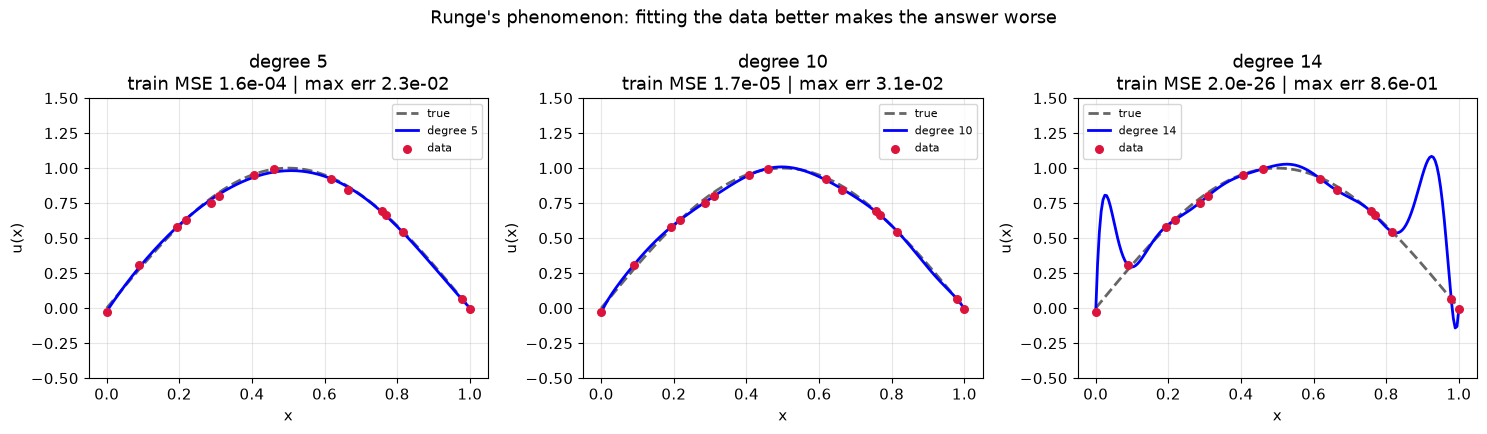

   degree    train MSE    max error
        5    1.624e-04    2.279e-02
       10    1.682e-05    3.091e-02
       14    1.993e-26    8.581e-01


In [4]:
from numpy.polynomial import Polynomial

degrees = [5, 10, 14]          # 14 = n_train - 1, the exact-interpolation degree
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
poly_err = {}

for ax, degree in zip(axes, degrees):
    poly = Polynomial.fit(x_train, y_train, degree)
    y_poly = poly(x_test)
    train_mse = np.mean((poly(x_train) - y_train) ** 2)
    max_err = np.max(np.abs(y_poly - y_exact))
    poly_err[degree] = (train_mse, max_err)

    ax.plot(x_test, y_exact, "k--", alpha=.6, lw=2, label="true")
    ax.plot(x_test, y_poly, "b-", lw=2, label=f"degree {degree}")
    ax.scatter(x_train, y_train, s=30, c="crimson", zorder=5, label="data")
    ax.set(xlabel="x", ylabel="u(x)", ylim=(-0.5, 1.5),
           title=f"degree {degree}\ntrain MSE {train_mse:.1e} | max err {max_err:.1e}")
    ax.legend(fontsize=8)

plt.suptitle("Runge's phenomenon: fitting the data better makes the answer worse",
             fontsize=13)
plt.tight_layout(); plt.show()

print(f"  {'degree':>7s} {'train MSE':>12s} {'max error':>12s}")
for d, (tm, me) in poly_err.items():
    print(f"  {d:>7d} {tm:>12.3e} {me:>12.3e}")

Look at the two columns. As the degree rises the **training** error falls while the **actual** error
explodes. Degree 14 passes through every point and is wildly wrong between them,
oscillating hardest near the boundaries — Runge's phenomenon.

The polynomial has no notion of "smooth"; it only knows "pass through the dots".
More capacity, spent badly, made it worse.

So we want a function class that is flexible but does not do this. That is the case
for neural networks — and to understand them we start with a single neuron.

## Part 2 — The perceptron

The building block. A perceptron weights its inputs, adds a bias, and passes the
result through an activation function $g$:

$$z = \sum_i w_i x_i + b = w^\top x + b, \qquad a = g(z)$$

<img src="figs/perceptron.png" width="470"/>

With $g$ the identity this *is* linear regression. Let's write it in NumPy and
train it by hand so nothing is hidden — including the two gradients.

In [5]:
class LinearPerceptron:
    """A single perceptron with no activation: a = X.w + b."""

    def __init__(self, n_inputs, seed=SEED):
        rng = np.random.default_rng(seed)
        self.w = rng.normal(0, 0.5, n_inputs)
        self.b = 0.0

    def forward(self, X):
        return X @ self.w + self.b


def train_linear_perceptron(model, X, y, lr=0.1, epochs=300):
    """Plain gradient descent on mean squared error, written out in full."""
    n, losses = len(X), []
    for _ in range(epochs):
        pred = model.forward(X)
        error = pred - y
        losses.append(np.mean(error ** 2))
        # dL/dw = 2/n * X^T (pred - y);   dL/db = 2/n * sum(pred - y)
        model.w -= lr * (2.0 / n * X.T @ error)
        model.b -= lr * (2.0 / n * error.sum())
    return losses


# A linearly separable 2D example: the perceptron handles this fine.
rng = np.random.default_rng(SEED)
A_pts = rng.normal([-1.5, -1.0], 0.6, (30, 2))
B_pts = rng.normal([1.5, 1.2], 0.6, (30, 2))
X_sep = np.vstack([A_pts, B_pts])
y_sep = np.hstack([np.zeros(len(A_pts)), np.ones(len(B_pts))])

p_sep = LinearPerceptron(2)
loss_sep = train_linear_perceptron(p_sep, X_sep, y_sep)
acc_sep = np.mean((p_sep.forward(X_sep) > 0.5) == y_sep)
print(f"linearly separable data: final loss {loss_sep[-1]:.4f}, "
      f"accuracy {acc_sep:.1%}")

linearly separable data: final loss 0.0202, accuracy 100.0%


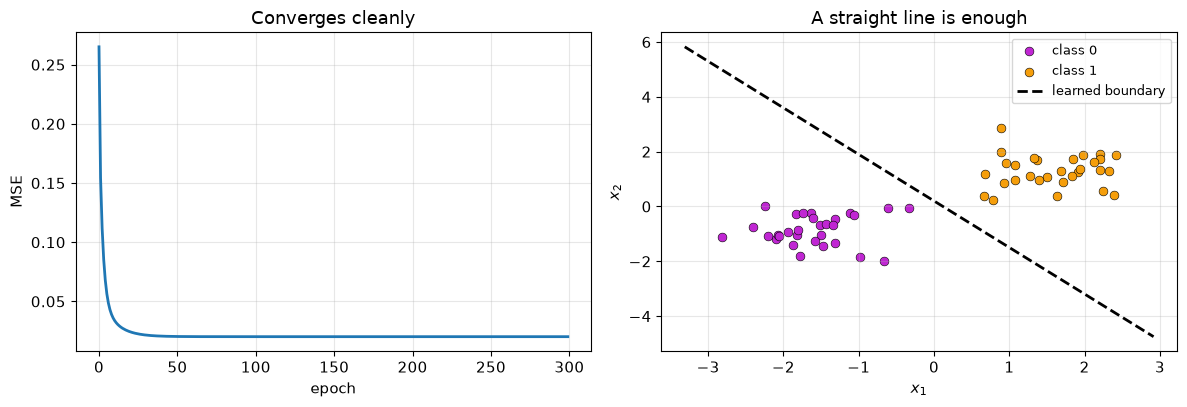

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(loss_sep, lw=2)
ax[0].set(xlabel="epoch", ylabel="MSE", title="Converges cleanly")

ax[1].scatter(*A_pts.T, s=40, c="#c026d3", label="class 0", edgecolor="k", lw=.4)
ax[1].scatter(*B_pts.T, s=40, c="#f59e0b", label="class 1", edgecolor="k", lw=.4)
gx = np.linspace(X_sep[:, 0].min() - .5, X_sep[:, 0].max() + .5, 100)
ax[1].plot(gx, (0.5 - p_sep.b - p_sep.w[0] * gx) / p_sep.w[1], "k--", lw=2,
           label="learned boundary")
ax[1].set(xlabel="$x_1$", ylabel="$x_2$", title="A straight line is enough")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## Part 3 — Where the linear model stops

Now the same perceptron on data that is *not* linearly separable: two classes in
interleaved bands. This is the dataset from the SciML course notebook, kept
identical so the pictures match.

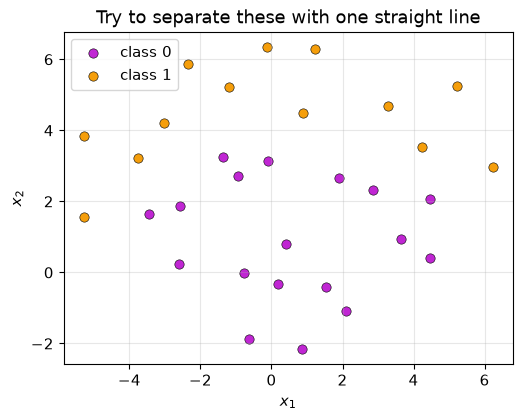

In [7]:
# Two interleaved bands -- not separable by any straight line.
np.random.seed(42)

class0_X = np.array([
    [-2.75, 0.27], [-3.63, 1.20], [-2.51, 1.95], [-1.85, 3.02],
    [-0.81, 2.54], [0.03, 3.28], [1.82, 3.23], [3.37, 2.48],
    [4.76, 1.96], [4.74, 0.82], [3.22, 1.02], [0.38, 1.22],
    [-0.62, -0.04], [0.52, -0.44], [1.72, -0.31], [2.29, -1.63],
    [0.87, -1.84], [-0.87, -1.52]])
class1_X = np.array([
    [-5.33, 2.15], [-4.88, 3.79], [-3.99, 3.16], [-2.98, 4.30],
    [-1.91, 6.07], [-1.06, 4.89], [0.78, 5.01], [-0.22, 6.47],
    [1.43, 6.11], [2.98, 4.41], [4.50, 3.61], [5.13, 4.95],
    [6.37, 3.01]])
class0_X = class0_X + np.random.normal(0, 0.3, class0_X.shape)
class1_X = class1_X + np.random.normal(0, 0.3, class1_X.shape)

X_nl = np.vstack([class0_X, class1_X])
y_nl = np.hstack([np.zeros(len(class0_X)), np.ones(len(class1_X))])

plt.figure(figsize=(5.8, 5))
plt.scatter(*class0_X.T, s=45, c="#c026d3", label="class 0", edgecolor="k", lw=.4)
plt.scatter(*class1_X.T, s=45, c="#f59e0b", label="class 1", edgecolor="k", lw=.4)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Try to separate these with one straight line")
plt.legend(); plt.gca().set_aspect("equal"); plt.show()

### Measure the ceiling for a straight line, do not eyeball it

Rather than eyeball it, measure the ceiling: fit the best possible linear
classifier and read its accuracy. That number is the bar any nonlinearity has to
beat.

In [8]:
from sklearn.linear_model import LogisticRegression


def best_linear_accuracy(features, labels):
    """Accuracy of the best linear classifier on these features."""
    clf = LogisticRegression(max_iter=5000, C=1e4).fit(features, labels)
    return clf.score(features, labels), clf


acc_X, clf_X = best_linear_accuracy(X_nl, y_nl)
print(f"best linear classifier on the raw input space: {acc_X:.1%}")
print("No straight line does better. The remaining errors are structural,")
print("not a training failure -- the classes are genuinely interleaved.")

best linear classifier on the raw input space: 87.1%
No straight line does better. The remaining errors are structural,
not a training failure -- the classes are genuinely interleaved.


### The fix: a linear map, then a nonlinearity

Here is the central idea of the module, and it is geometric.

A hidden layer does two things in sequence:

1. $y = W_1 x$ — a **linear map**: rotate, scale, shear.
2. $z = \mathrm{ReLU}(y) = \max(0, y)$ — a **nonlinearity**: clamp everything
   negative to zero.

Watch what each step does to the *shape* of the data. We use the specific map from
the course's interactive demo — a rotation of $-59^\circ$ with scale 2 — and
measure how well a straight line does in each space.

<img src="figs/why-activation.png" width="620"/>

> The interactive version, with sliders for rotation, scale and ReLU slope, is in
> the SciML course:
> [**ReLU and the importance of non-linear transformation**](https://kks32-courses.github.io/sciml/00-mlp/relu.html).

In [9]:
angle, scale = np.deg2rad(-59), 2.0
W1 = np.array([[np.cos(angle) * scale, -np.sin(angle) * scale],
               [np.sin(angle) * scale,  np.cos(angle) * scale]]).T

Y_lin = X_nl @ W1                 # after the linear map
Z_relu = np.maximum(0, Y_lin)     # after ReLU

acc_Y, _ = best_linear_accuracy(Y_lin, y_nl)
acc_Z, clf_Z = best_linear_accuracy(Z_relu, y_nl)

print(f"  {'space':<34s} {'best linear accuracy':>22s}")
print(f"  {'X   input':<34s} {acc_X:>21.1%}")
print(f"  {'Y   after the linear map':<34s} {acc_Y:>21.1%}")
print(f"  {'Z   after ReLU':<34s} {acc_Z:>21.1%}")
print()
print(f"  coordinates clamped to zero by ReLU: {(Z_relu == 0).mean():.0%}")

  space                                best linear accuracy
  X   input                                          87.1%
  Y   after the linear map                           87.1%
  Z   after ReLU                                    100.0%

  coordinates clamped to zero by ReLU: 34%


- $X$ and $Y$ give **exactly the same accuracy.** The rotation and scaling achieved
  *nothing*. That is not bad luck: an invertible linear map cannot change which
  sets are linearly separable, because it moves the points and moves every
  candidate boundary along with them.
- $Z$ is **perfectly separable.** The only new ingredient was $\max(0,\cdot)$.

So ReLU is not "a squashing function" or an implementation detail. It **folds** the
plane: everything on the negative side of each axis collapses onto zero, and
folding can bring two interleaved bands onto the same side of a line. About a third
of the coordinates got clamped, and that clamping *is* the fold.

Let's look at it.

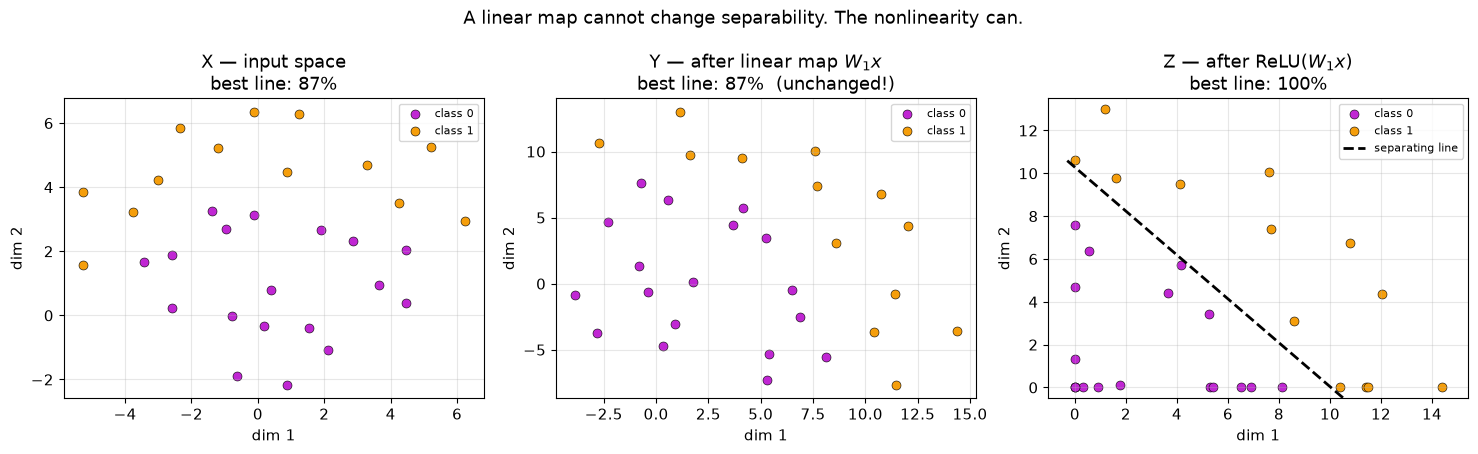

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
n0 = len(class0_X)
titles = [f"X — input space\nbest line: {acc_X:.0%}",
          f"Y — after linear map $W_1x$\nbest line: {acc_Y:.0%}  (unchanged!)",
          f"Z — after ReLU$(W_1x)$\nbest line: {acc_Z:.0%}"]

for ax, F, title in zip(axes, [X_nl, Y_lin, Z_relu], titles):
    ax.scatter(*F[:n0].T, s=42, c="#c026d3", label="class 0", edgecolor="k", lw=.4)
    ax.scatter(*F[n0:].T, s=42, c="#f59e0b", label="class 1", edgecolor="k", lw=.4)
    ax.set(xlabel="dim 1", ylabel="dim 2", title=title)
    ax.legend(fontsize=8)

w, b = clf_Z.coef_[0], clf_Z.intercept_[0]
zx = np.linspace(Z_relu[:, 0].min() - .3, Z_relu[:, 0].max() + .3, 100)
axes[2].plot(zx, -(b + w[0] * zx) / w[1], "k--", lw=2, label="separating line")
axes[2].set_ylim(Z_relu[:, 1].min() - .5, Z_relu[:, 1].max() + .5)
axes[2].legend(fontsize=8)

plt.suptitle("A linear map cannot change separability. The nonlinearity can.",
             fontsize=13)
plt.tight_layout(); plt.show()

In panel Z the classes sit on opposite sides of a line, and the points
squashed onto the axes are exactly the ones ReLU clamped.

That is what a hidden layer *is*: a linear map that positions the data, and a
nonlinearity that folds it. Stack a few and you can fold a space into almost any
shape — which is the intuition behind the theorem in Part 6.

## Part 4 — Why the nonlinearity is not optional

The geometry above is suggestive. Here is the proof.

Take a network of linear layers with **no** activation between them:

$$h_1 = W_1 x + b_1, \qquad h_2 = W_2 h_1 + b_2$$

Substitute the first into the second:

$$h_2 = W_2(W_1 x + b_1) + b_2
= \underbrace{(W_2 W_1)}_{\tilde W} x + \underbrace{(W_2 b_1 + b_2)}_{\tilde b}$$

That is **one** linear layer. However many you stack, the whole network computes a
single affine function. Depth without nonlinearity buys exactly nothing.

<img src="figs/linear-network-failure.png" width="600"/>

Confirm it twice: collapse a deep linear stack by hand, then watch one fail on our
$\sin(\pi x)$ problem.

In [11]:
def make_linear_stack(width=32, depth=3, d_in=1):
    """A deep network with NO activation functions."""
    layers, d = [], d_in
    for _ in range(depth - 1):
        layers += [nn.Linear(d, width)]
        d = width
    layers += [nn.Linear(d, 1)]
    return nn.Sequential(*layers)


stack = make_linear_stack()
n_params = sum(p.numel() for p in stack.parameters())

# Collapse it: multiply the weight matrices together.
W = torch.eye(1)
for layer in stack:
    W = layer.weight.detach() @ W

print(f"{n_params} parameters across {len(stack)} Linear layers, 0 activations")
print(f"collapses to a single {tuple(W.shape)} matrix: {W.numpy().ravel()}")
print(f"\nso those {n_params} parameters have exactly 1 slope "
      "(plus one bias) of real freedom")

1153 parameters across 3 Linear layers, 0 activations
collapses to a single (1, 1) matrix: [0.36]

so those 1153 parameters have exactly 1 slope (plus one bias) of real freedom


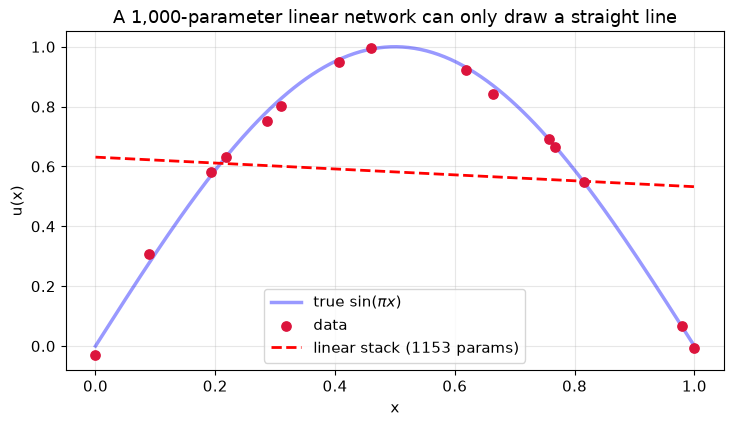

max error of the linear stack: 0.6312


In [12]:
xt = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1)
yt = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
xg = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1)


def fit(model, epochs=3000, lr=1e-2):
    """Train a 1-D model on the 15 sparse samples; return its prediction."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        nn.MSELoss()(model(xt), yt).backward()
        opt.step()
    with torch.no_grad():
        return model(xg).numpy().ravel()


torch.manual_seed(SEED)
pred_linear = fit(make_linear_stack(width=32, depth=3))

plt.figure(figsize=(8.5, 4.4))
plt.plot(x_test, y_exact, "b-", alpha=.4, lw=2.5, label=r"true $\sin(\pi x)$")
plt.scatter(x_train, y_train, s=45, c="crimson", zorder=5, label="data")
plt.plot(x_test, pred_linear, "r--", lw=2,
         label=f"linear stack ({n_params} params)")
plt.xlabel("x"); plt.ylabel("u(x)")
plt.title("A 1,000-parameter linear network can only draw a straight line")
plt.legend(); plt.show()

print(f"max error of the linear stack: {np.abs(pred_linear - y_exact).max():.4f}")

A thousand parameters, and the best it can do is the least-squares straight
line. The curve is unreachable — not because training failed, but because it is not
in the function class.

### ReLU folds; tanh stays twice-differentiable

<img src="figs/activation-functions.png" width="700"/>

- **ReLU** $\max(0,z)$ — default for classification and deep vision. Cheap, and
  the folding picture above is exactly what it does.
- **tanh** — smooth, and the usual choice for regression and for **PINNs**, because
  Module 4 differentiates the network twice and ReLU's second derivative is zero
  almost everywhere.
- **sigmoid** — historically important, squashes to $(0,1)$, largely superseded for
  hidden layers.

We use `tanh` from here on, for continuity with Module 4.

## Part 5 — One hidden layer, and it works

Same 15 noisy points that the degree-14 polynomial mangled. Now with one hidden
layer and `tanh`.

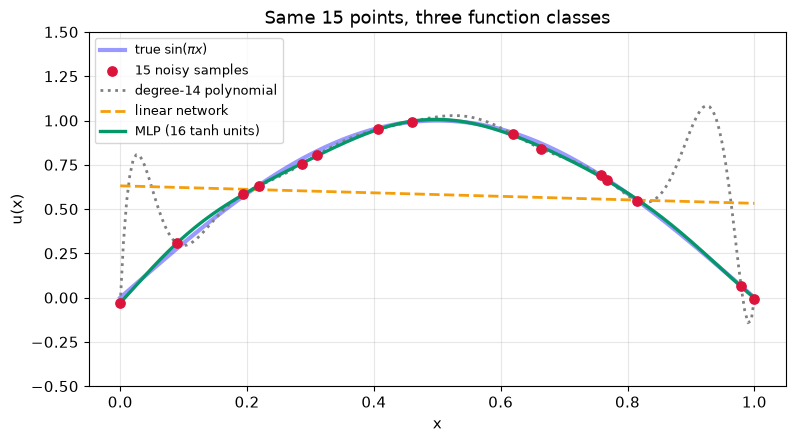

  model                        max error
  degree-14 polynomial            0.8581
  linear network                  0.6312
  MLP, 16 tanh units              0.0345


In [13]:
def make_mlp(width=32, depth=3, d_in=1, d_out=1):
    """Linear -> tanh -> ... -> Linear."""
    layers, d = [], d_in
    for _ in range(depth - 1):
        layers += [nn.Linear(d, width), nn.Tanh()]
        d = width
    layers += [nn.Linear(d, d_out)]
    return nn.Sequential(*layers)


torch.manual_seed(SEED)
mlp1d = make_mlp(width=16, depth=3, d_in=1)
pred_mlp = fit(mlp1d)

poly14 = Polynomial.fit(x_train, y_train, 14)(x_test)

plt.figure(figsize=(9, 4.6))
plt.plot(x_test, y_exact, "b-", alpha=.4, lw=3, label=r"true $\sin(\pi x)$")
plt.scatter(x_train, y_train, s=45, c="crimson", zorder=5, label="15 noisy samples")
plt.plot(x_test, poly14, ":", color="grey", lw=2, label="degree-14 polynomial")
plt.plot(x_test, pred_linear, "--", color="#f59e0b", lw=2, label="linear network")
plt.plot(x_test, pred_mlp, "-", color="#059669", lw=2.4, label="MLP (16 tanh units)")
plt.ylim(-0.5, 1.5)
plt.xlabel("x"); plt.ylabel("u(x)")
plt.title("Same 15 points, three function classes")
plt.legend(fontsize=9); plt.show()

print(f"  {'model':<26s} {'max error':>11s}")
for name, p in (("degree-14 polynomial", poly14),
                ("linear network", pred_linear),
                ("MLP, 16 tanh units", pred_mlp)):
    print(f"  {name:<26s} {np.abs(p - y_exact).max():>11.4f}")

The MLP fits the *shape* rather than the dots. It has ample capacity to
oscillate like the polynomial and does not, because smooth functions are what
gradient descent on a tanh network reaches first.

### Past a few neurons, the seed matters as much as the width

One run per width would mislead — the same architecture lands in a different
minimum on every seed. Three seeds per width, and we plot the spread.

  width   1   max error  mean 0.6790   min 0.6787   max 0.6793   seed spread 1.0x


  width   2   max error  mean 0.2452   min 0.0245   max 0.6779   seed spread 27.7x


  width   4   max error  mean 0.0205   min 0.0191   max 0.0214   seed spread 1.1x


  width   8   max error  mean 0.0333   min 0.0286   max 0.0360   seed spread 1.3x


  width  16   max error  mean 0.0351   min 0.0349   max 0.0353   seed spread 1.0x


  width  32   max error  mean 0.0376   min 0.0358   max 0.0387   seed spread 1.1x


  width  64   max error  mean 0.0380   min 0.0353   max 0.0398   seed spread 1.1x


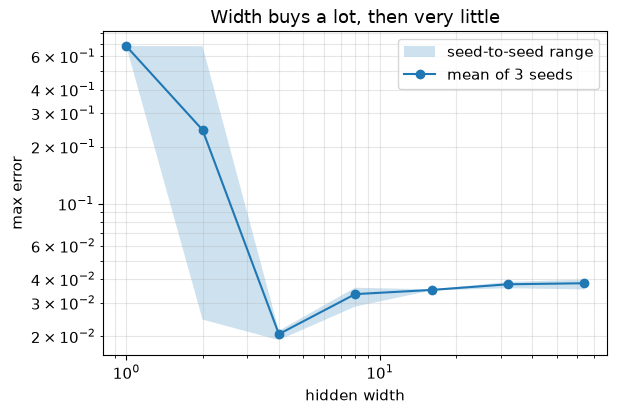

In [14]:
widths = [1, 2, 4, 8, 16, 32, 64]
seeds = [0, 1, 2]
errs = np.zeros((len(widths), len(seeds)))

for i, w in enumerate(widths):
    for j, s in enumerate(seeds):
        torch.manual_seed(s)
        p = fit(make_mlp(width=w, depth=3, d_in=1), epochs=3000)
        errs[i, j] = np.abs(p - y_exact).max()
    print(f"  width {w:>3d}   max error  mean {errs[i].mean():.4f}   "
          f"min {errs[i].min():.4f}   max {errs[i].max():.4f}   "
          f"seed spread {errs[i].max() / errs[i].min():.1f}x")

plt.figure(figsize=(6.5, 4.2))
plt.fill_between(widths, errs.min(1), errs.max(1), alpha=.22,
                 label="seed-to-seed range")
plt.loglog(widths, errs.mean(1), "o-", label="mean of 3 seeds")
plt.xlabel("hidden width"); plt.ylabel("max error")
plt.title("Width buys a lot, then very little")
plt.legend(); plt.grid(True, which="both", alpha=.3); plt.show()

The first few neurons buy nearly everything; after that the mean barely moves, and the shaded band shows why the
comparison stops meaning much — **changing the random seed moves the error about as
much as changing the width does.**

- Below some width the model *cannot* represent the target. That part is real
  capacity, and you can see it.
- Above it you are no longer capacity-limited but data- and optimiser-limited.

Report seed spread before claiming one architecture beats another.

## Part 6 — The Universal Approximation Theorem

Why should any of that have worked?

> **Theorem (Cybenko 1989, Hornik 1991).** Let $\sigma$ be a continuous,
> non-polynomial activation and $K \subset \mathbb{R}^d$ compact. Then finite sums
> $$g(x) = \sum_{i=1}^{N} \alpha_i\,\sigma(w_i^\top x + b_i)$$
> are **dense** in $C(K)$: for every continuous $f$ and every $\varepsilon > 0$
> there exists such a $g$ with $\sup_{x \in K}|f(x) - g(x)| < \varepsilon$.

One hidden layer, wide enough, approximates any continuous function on a bounded
domain to any accuracy you name.

### Where the capacity comes from

With ReLU the proof is constructive — and it is the folding picture from Part 3, in
one dimension. A single ReLU is a hinge with its kink at $x = -b/w$. Two hinges,
subtracted, make a step. A sum of steps is a staircase, and a staircase
approximates any continuous function.

<img src="figs/relu-decomposition-sinpi.png" width="700"/>

Each neuron contributes one breakpoint, so width buys resolution:

<img src="figs/uat-approximation-progression.png" width="700"/>

### What the theorem does not say

This is the part that matters in practice, and it is usually skipped.

| The theorem promises | The theorem is silent on |
| --- | --- |
| A good approximator **exists** | How **wide** — the bound can be exponential in $d$ |
| For any continuous $f$ on compact $K$ | Anything **outside** $K$; extrapolation is unbounded |
| That the weights exist | Whether **gradient descent finds them** |
| Accuracy on $K$ | **Generalisation** from finitely many samples |

An existence result, not an algorithm. Part 5 already measured two of these: the
width caveat, and the optimiser caveat — the seed spread *was* the optimiser
caveat.

There is also a hard limit: $f$ must be **continuous**. A network with continuous
activations is continuous, so it can never represent a true jump, only approximate
one with a steep ramp. That matters for cracking, contact, and liquefaction
triggering.

## Part 7 — Automatic differentiation

Training needed the gradient of the loss with respect to every weight. Reverse-mode
AD returns all of them in a single backward pass, at roughly the cost of one
forward pass — and it differentiates with respect to **inputs** just as happily,
which is the mechanism every PINN is built on.

That deserves more than a paragraph, so it has its own notebook:

> **[Automatic differentiation and gradient descent](02b-automatic-differentiation.ipynb)**
> — computational graphs, forward versus reverse mode, the backward-pass
> algorithm, the PyTorch API, and gradient descent with its variants and
> learning-rate behaviour.

Read that before the PINN notebooks; they assume it.

## Part 8 — Application: back to the cantilever

Everything so far lived on a 1D test function so the mechanism stayed visible. Now
use it on Module 1's data, and ask two questions:

1. What does a linear model do on the **raw** features, without the logarithm
   insight?
2. Can an MLP recover the physics without being given it?

`cantilever_sweep.csv` reproduces the Module 1 sweep exactly. The beam is elastic,
so `period` has a closed form and `make_sweep_csv.py` regenerates the table with no
allocation needed.

In [15]:
df = pd.read_csv(find_data("cantilever_sweep.csv"))
features = ["NodalMass", "LCol", "E"]
X_raw = df[features].to_numpy(dtype=float)
y_raw = df["period"].to_numpy(dtype=float)

print(f"{len(df)} runs")
print("feature ranges (note how different the scales are):")
for name, col in zip(features, X_raw.T):
    print(f"  {name:>10s}  {col.min():>8.1f} .. {col.max():>8.1f}")
print(f"  {'period':>10s}  {y_raw.min():>8.4f} .. {y_raw.max():>8.4f} s")
df.head()

75 runs
feature ranges (note how different the scales are):
   NodalMass       4.2 ..      5.0
        LCol     100.0 ..    500.0
           E    3600.0 ..   5000.0
      period    0.1010 ..   1.4530 s


,NodalMass,LCol,E,A,Iz,period,k_theory,top_disp_at_100kip
0,4.19,100,3600,3600.0,1080000.0,0.119087,11664.000,0.008573
1,4.19,100,4227,3600.0,1080000.0,0.109900,13695.480,0.007302
2,4.19,100,5000,3600.0,1080000.0,0.101048,16200.000,0.006173
3,4.19,200,3600,3600.0,1080000.0,0.336828,1458.000,0.068587
4,4.19,200,4227,3600.0,1080000.0,0.310845,1711.935,0.058413


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_raw = LinearRegression().fit(X_raw, y_raw)
pred_raw = lin_raw.predict(X_raw)
rel_err = np.abs(pred_raw - y_raw) / y_raw * 100

print("RAW-feature linear regression")
for name, c in zip(features, lin_raw.coef_):
    print(f"  {name:>10s}  {c:+.6g}")
print(f"\n  R2 = {r2_score(y_raw, pred_raw):.4f}")
print(f"  relative error:  median {np.median(rel_err):.1f}%   "
      f"max {rel_err.max():.1f}%")
neg = pred_raw < 0
print(f"\n  physically impossible predictions (T < 0): {neg.sum()} of {len(y_raw)}")
if neg.any():
    print(df.loc[neg, features].assign(true_T=y_raw[neg],
                                       pred_T=pred_raw[neg]).to_string(index=False))

RAW-feature linear regression
   NodalMass  +0.0708112
        LCol  +0.00293847
           E  -7.57117e-05

  R2 = 0.9841
  relative error:  median 8.0%   max 121.4%

  physically impossible predictions (T < 0): 2 of 75
 NodalMass  LCol    E   true_T    pred_T
      4.19   100 5000 0.101048 -0.021646
      4.39   100 5000 0.103432 -0.007484


$R^2 = 0.98$ would pass most reviews. And the model predicts a **negative
fundamental period** — the average was hiding a >100% error on the stiffest
columns. Always plot residuals against a physical variable:

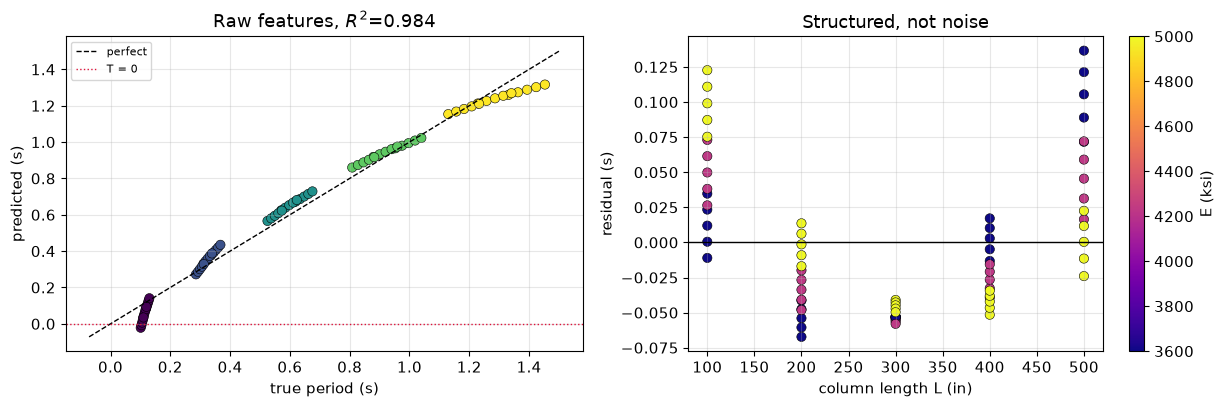

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].scatter(y_raw, pred_raw, c=df["LCol"], cmap="viridis", s=45,
              edgecolor="k", lw=.4)
lims = [min(y_raw.min(), pred_raw.min()) - .05, y_raw.max() + .05]
ax[0].plot(lims, lims, "k--", lw=1, label="perfect")
ax[0].axhline(0, color="crimson", lw=1, ls=":", label="T = 0")
ax[0].set(xlabel="true period (s)", ylabel="predicted (s)",
          title=f"Raw features, $R^2$={r2_score(y_raw, pred_raw):.3f}")
ax[0].legend(fontsize=8)

sc = ax[1].scatter(df["LCol"], y_raw - pred_raw, c=df["E"], cmap="plasma", s=45,
                   edgecolor="k", lw=.4)
ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="column length L (in)", ylabel="residual (s)",
          title="Structured, not noise")
plt.colorbar(sc, ax=ax[1], label="E (ksi)")
plt.tight_layout(); plt.show()

Curved residuals: a straight line trying to fit $L^{1.5}$. The *model
class* is wrong, and no amount of extra data fixes that. Module 1's fix, for
comparison:

In [18]:
lin_log = LinearRegression().fit(np.log(X_raw), np.log(y_raw))
print("LOG-feature linear regression (Module 1)")
for name, c in zip(features, lin_log.coef_):
    print(f"  log {name:>10s}  {c:+.4f}")
print(f"\n  R2 = {r2_score(np.log(y_raw), lin_log.predict(np.log(X_raw))):.6f}")
print("\n  exact exponents of T = 2*pi*sqrt(M L^3 / 3EI):  +0.5, +1.5, -0.5")

LOG-feature linear regression (Module 1)
  log  NodalMass  +0.5000
  log       LCol  +1.5000
  log          E  -0.5000

  R2 = 1.000000

  exact exponents of T = 2*pi*sqrt(M L^3 / 3EI):  +0.5, +1.5, -0.5


### The MLP recovers the curvature without being given logarithms

No logarithms supplied. **Standardise first** — the features span 4.19 to 5000, and
gradient descent on that spread barely moves. Note that standardising is an
*affine* map, so by Part 4 it cannot linearise a power law; the nonlinearity is
still there for the network to find.

In [19]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X_raw, y_raw, test_size=0.2, random_state=SEED)
x_mu, x_sd = Xtr.mean(0), Xtr.std(0)
y_mu, y_sd = ytr.mean(), ytr.std()

to_t = lambda X: torch.tensor((X - x_mu) / x_sd, dtype=torch.float32)
to_y = lambda v: torch.tensor((v - y_mu) / y_sd, dtype=torch.float32).unsqueeze(1)
from_t = lambda t: t.detach().numpy().ravel() * y_sd + y_mu

Xtr_t, ytr_t, Xte_t, yte_t = to_t(Xtr), to_y(ytr), to_t(Xte), to_y(yte)


def train3d(model, epochs=4000, lr=5e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"train": [], "test": []}
    for _ in range(epochs):
        opt.zero_grad()
        loss = nn.MSELoss()(model(Xtr_t), ytr_t)
        loss.backward(); opt.step(); sched.step()
        hist["train"].append(loss.item())
        with torch.no_grad():
            hist["test"].append(nn.MSELoss()(model(Xte_t), yte_t).item())
    return hist


torch.manual_seed(SEED)
mlp3d = make_mlp(width=32, depth=3, d_in=3)
hist3d = train3d(mlp3d)

with torch.no_grad():
    pred_all = from_t(mlp3d(to_t(X_raw)))
    pred_te = from_t(mlp3d(Xte_t))
rel_mlp = np.abs(pred_all - y_raw) / y_raw * 100

print("                          R2 (test)   median rel err   max rel err   T<0")
print(f"  raw linear regression     {r2_score(y_raw, pred_raw):.4f}      "
      f"{np.median(rel_err):>6.1f}%      {rel_err.max():>7.1f}%    {(pred_raw<0).sum()}")
print(f"  raw MLP                   {r2_score(yte, pred_te):.4f}      "
      f"{np.median(rel_mlp):>6.1f}%      {rel_mlp.max():>7.1f}%    {(pred_all<0).sum()}")

                          R2 (test)   median rel err   max rel err   T<0
  raw linear regression     0.9841         8.0%        121.4%    2
  raw MLP                   1.0000         0.1%          1.5%    0


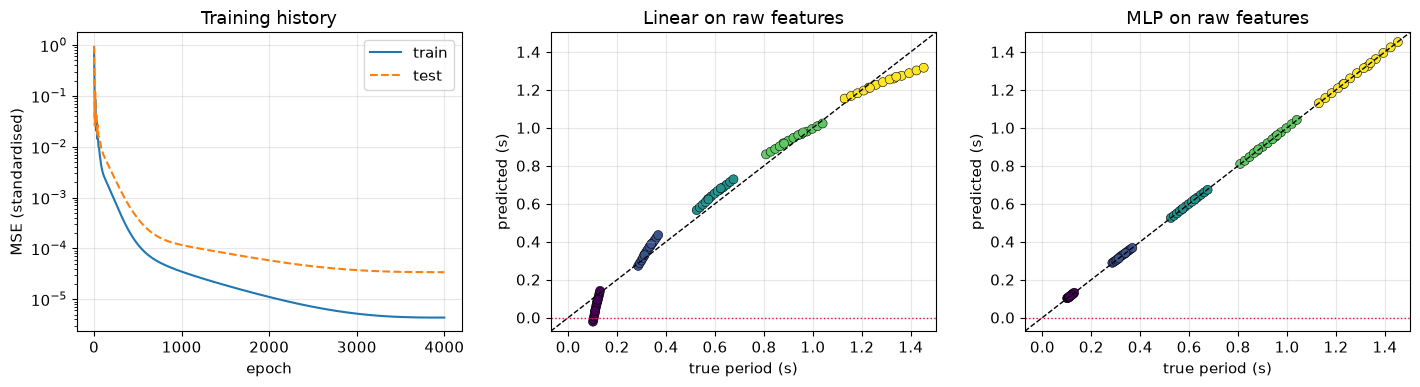

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4))
ax[0].semilogy(hist3d["train"], label="train")
ax[0].semilogy(hist3d["test"], "--", label="test")
ax[0].set(xlabel="epoch", ylabel="MSE (standardised)", title="Training history")
ax[0].legend()

for a, p, t in ((ax[1], pred_raw, "Linear on raw features"),
                (ax[2], pred_all, "MLP on raw features")):
    a.scatter(y_raw, p, c=df["LCol"], cmap="viridis", s=42, edgecolor="k", lw=.4)
    a.plot(lims, lims, "k--", lw=1)
    a.axhline(0, color="crimson", lw=1, ls=":")
    a.set(xlabel="true period (s)", ylabel="predicted (s)", title=t,
          xlim=lims, ylim=lims)
plt.tight_layout(); plt.show()

The MLP had to discover the $L^{1.5}$ curvature from 60 training runs. It
was not told.

That is the trade this session turns on. The linear model, given the right
features, was exact and its three coefficients were readable physics. The MLP needs
no such insight and returns a few thousand weights that mean nothing on their
own — which is the problem **Module 3** attacks.

### optional — design sensitivities from the surrogate

The Part 7 trick, now on the engineering model: differentiate the trained surrogate
for $\partial T/\partial L$, checkable against $\partial T/\partial L = 1.5\,T/L$.

In [21]:
probe = df[df["LCol"].between(150, 500)].copy()
xp = to_t(probe[features].to_numpy(dtype=float)).clone().requires_grad_(True)
T_std = mlp3d(xp)
grads, = torch.autograd.grad(T_std, xp, torch.ones_like(T_std))
j = features.index("LCol")
dT_dL = grads[:, j].numpy() * y_sd / x_sd[j]
dT_dL_exact = 1.5 * probe["period"].to_numpy() / probe["LCol"].to_numpy()

print(f"  {'L':>5s} {'T':>8s} {'dT/dL (AD)':>12s} {'exact':>12s} {'err':>7s}")
for i in range(0, len(probe), max(1, len(probe) // 8)):
    e = abs(dT_dL[i] - dT_dL_exact[i]) / abs(dT_dL_exact[i]) * 100
    print(f"  {probe['LCol'].iloc[i]:>5.0f} {probe['period'].iloc[i]:>8.4f} "
          f"{dT_dL[i]:>12.6f} {dT_dL_exact[i]:>12.6f} {e:>6.1f}%")

      L        T   dT/dL (AD)        exact     err
    200   0.3368     0.002498     0.002526    1.1%
    400   0.8792     0.003311     0.003297    0.4%
    200   0.2925     0.002159     0.002194    1.6%
    500   1.3628     0.003907     0.004089    4.4%
    300   0.5977     0.002970     0.002988    0.6%
    500   1.1825     0.003480     0.003547    1.9%
    400   1.0186     0.003863     0.003820    1.1%
    200   0.3392     0.002519     0.002544    1.0%
    400   0.8822     0.003338     0.003308    0.9%


### optional — what actually limited the accuracy

Our targets came from a closed-form formula, so they carry **no noise**. Real
simulation output does: solver tolerances, mesh sensitivity, modelling choices.
Run a 2x2 — two architectures, two noise levels.

<img src="figs/overfitting-demo.png" width="700"/>

In [22]:
NOISE = 0.02
rng2 = np.random.default_rng(SEED)
y_noisy = y_raw * (1 + NOISE * rng2.standard_normal(len(y_raw)))

rows = []
for case, yv in (("noiseless", y_raw), (f"{NOISE:.0%} noise", y_noisy)):
    Xa, Xb, ya, yb = train_test_split(X_raw, yv, test_size=0.2, random_state=SEED)
    xm, xs, ym, ys = Xa.mean(0), Xa.std(0), ya.mean(), ya.std()
    f = lambda X: torch.tensor((X - xm) / xs, dtype=torch.float32)
    g = lambda v: torch.tensor((v - ym) / ys, dtype=torch.float32).unsqueeze(1)
    for tag, w, d in (("width 32, depth 3", 32, 3), ("width 256, depth 5", 256, 5)):
        torch.manual_seed(SEED)
        m = make_mlp(width=w, depth=d, d_in=3)
        opt = torch.optim.Adam(m.parameters(), lr=5e-3)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=6000)
        for _ in range(6000):
            opt.zero_grad(); nn.MSELoss()(m(f(Xa)), g(ya)).backward()
            opt.step(); sch.step()
        with torch.no_grad():
            tr = nn.MSELoss()(m(f(Xa)), g(ya)).item()
            te = nn.MSELoss()(m(f(Xb)), g(yb)).item()
        rows.append((case, tag, sum(p.numel() for p in m.parameters()), tr, te, te / tr))

print(f"  {'data':<14s} {'architecture':<20s} {'params':>9s} {'train':>10s} "
      f"{'test':>10s} {'ratio':>14s}")
for c, t, n, tr, te, ra in rows:
    print(f"  {c:<14s} {t:<20s} {n:>9,} {tr:>10.2e} {te:>10.2e} {ra:>13,.0f}x")

  data           architecture            params      train       test          ratio
  noiseless      width 32, depth 3        1,217   6.79e-07   1.63e-05            24x
  noiseless      width 256, depth 5     198,657   8.74e-10   4.70e-04       537,734x
  2% noise       width 32, depth 3        1,217   4.98e-05   6.50e-03           130x
  2% noise       width 256, depth 5     198,657   2.30e-15   1.53e-02 6,666,587,748,274x


The oversized network **interpolates** — training loss to $10^{-11}$,
passing through all 60 points including the noise. But its **test** error is no
better and no worse than the small one's. The train/test ratio screams $10^7$ while
the predictions are fine.

> **Judge on test error, not the gap.** A large gap is evidence of interpolation,
> not automatically of bad predictions.

What *did* move the test error was the noise, for both architectures. On this
smooth 3D problem capacity is nearly free and **data quality is the binding
constraint** — which is the argument for putting physics in the loss.

## Summary

| | |
| --- | --- |
| **Fitting the data is not the goal** | The degree-14 polynomial passed through all 15 points and was the worst approximation of the three. |
| **A linear map cannot change separability** | Best linear accuracy was *identical* before and after $W_1x$; only $\max(0,\cdot)$ changed it. The nonlinearity **folds** the space. |
| **Depth without nonlinearity is nothing** | $W_2W_1 = \tilde W$. A 1,000-parameter linear net draws a straight line. |
| **UAT is an existence theorem** | Not how wide, not that SGD finds it, not that it generalises, and nothing outside the training domain. |
| **Report seed spread** | Changing the seed moved our error about as much as changing the width did. |
| **AD differentiates w.r.t. inputs** | Derivatives and design sensitivities for free — and the mechanism behind every PINN. |
| **A linear model in the right basis is unbeatable** | Module 1 got $R^2=1$ and readable exponents. Try feature engineering before reaching for a network. |
| **$R^2$ can hide a broken model** | 0.984 on raw features, with negative periods. |

### Interpretability, data cost and one-off solutions remain

- **Module 3 (XAI)** — the MLP replaced three physical exponents with thousands of
  opaque weights. XAI buys the interpretation back, on real liquefaction data.
- **Module 4 (PINNs)** — put the *governing equation* in the loss instead of data,
  and solve the very Poisson problem we opened this module with.
- **Module 5 (DeepONet)** — learn the whole solution operator rather than one
  solution.

### Go deeper

The full-length treatments, with the proofs and the interactive demos:

- [SciML — MLP and function approximation](https://kks32-courses.github.io/sciml/00-mlp/mlp.html)
- [SciML — ReLU, interactive](https://kks32-courses.github.io/sciml/00-mlp/relu.html)
- [SciML — Universal Approximation Theorem](https://kks32-courses.github.io/sciml/00-mlp/uat.html)
- [SciML — automatic differentiation](https://kks32-courses.github.io/sciml/00-mlp/ad.html)
- [SciML — gradient descent](https://kks32-courses.github.io/sciml/00-mlp/sgd.html)
- [SciML — regularization](https://kks32-courses.github.io/sciml/00-mlp/regularization.html)